<div align="center">

# 🧠💚 STRESS TRAJECTORY PREDICTION
## *A Machine Learning Approach to Mental Health Risk Assessment*

---

</div>

## 🎯 Project Mission

This project uses **Machine Learning** to identify individuals who may be at risk of developing chronic stress, enabling **early intervention** and support.

## 📌 Problem Definition

| Aspect | Description |
|--------|-------------|
| **Goal** | Predict if someone is at risk of growing stress |
| **Target** | `Stress_Risk` (Binary: "At Risk" vs "Not At Risk") |
| **Data** | "Maybe" responses removed — only Yes/No used |
| **Primary Metric** | **Recall** — catch as many at-risk individuals as possible |

## ⚠️ Why We Prioritize RECALL

In mental health screening, **missing someone who needs help is far worse than a false alarm**.

| Error Type | Real-World Impact |
|------------|------------------|
| **False Negative** ❌ | Missed at-risk person → No intervention → Potential crisis |
| **False Positive** ⚡ | Extra check-in → Minor inconvenience → Still helpful |

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, make_scorer)
from sklearn.utils import shuffle
from scipy.stats import chi2_contingency
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib, os

print("Libraries imported!")

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# Load Data
df = pd.read_csv('Mental Health Dataset.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset Shape: 292,364 rows × 17 columns

Columns: ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
# Understand the Data
print("DATA TYPES:")
print(df.dtypes)
print(f"\nMISSING VALUES:\n{df.isnull().sum()}")
print(f"\nDUPLICATES: {df.duplicated().sum():,}")

📊 DATA TYPES:
Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping_Struggles           object
Work_Interest              object
Social_Weakness            object
mental_health_interview    object
care_options               object
dtype: object

📊 MISSING VALUES:
Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings            

In [ ]:
# Check Original Target Variable
print("Original Growing_Stress Distribution:")
print(df['Growing_Stress'].value_counts())
print(f"\nPercentage:\n{(df['Growing_Stress'].value_counts(normalize=True) * 100).round(1)}")

📊 ORIGINAL Growing_Stress Distribution:
Growing_Stress
Maybe    99985
Yes      99653
No       92726
Name: count, dtype: int64

Percentage:
Growing_Stress
Maybe    34.2
Yes      34.1
No       31.7
Name: proportion, dtype: float64
Growing_Stress
Maybe    34.2
Yes      34.1
No       31.7
Name: proportion, dtype: float64


📊 TARGET (Stress_Risk) Distribution:
Stress_Risk
At Risk        199638
Not At Risk     92726
Name: count, dtype: int64

Percentage:
Stress_Risk
At Risk        68.3
Not At Risk    31.7
Name: proportion, dtype: float64


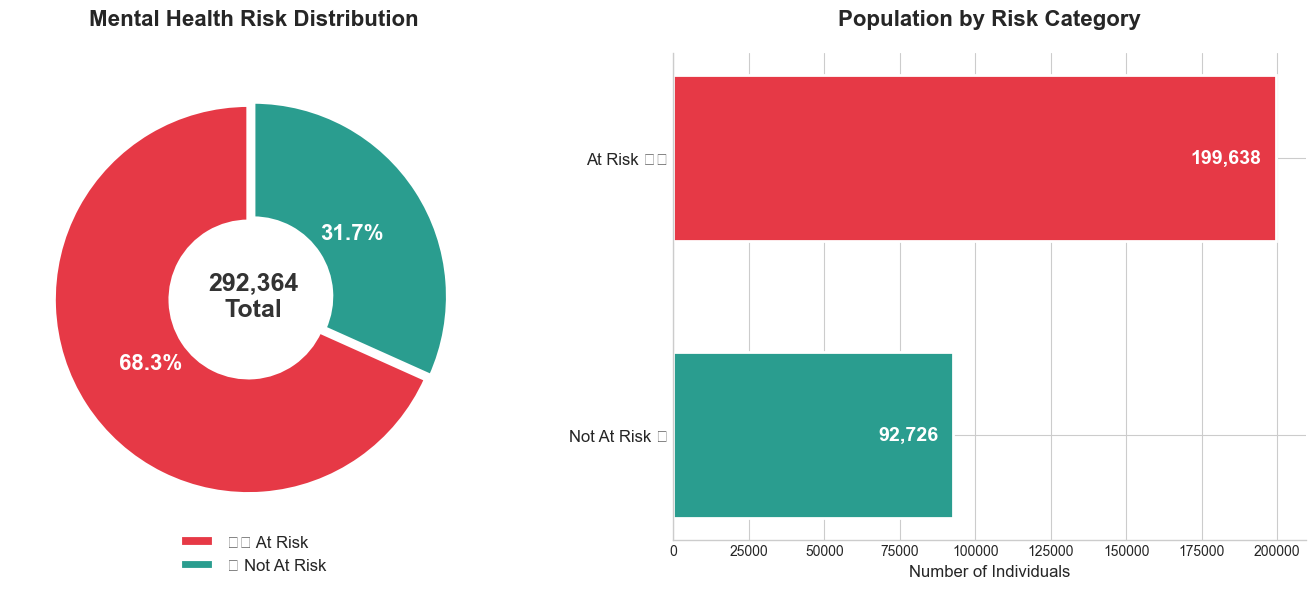


📊 Imbalance Ratio: 2.15
⚠️ Data is IMBALANCED - Using SMOTE & class_weight='balanced'


In [ ]:
# Create Binary Target — Remove "Maybe" observations
df['Stress_Risk'] = df['Growing_Stress'].map({'Yes': 'At Risk', 'No': 'Not At Risk'})
before = len(df)
df = df.dropna(subset=['Stress_Risk'])
print(f"Removed {before - len(df):,} 'Maybe' observations")
print(f"Remaining: {len(df):,} samples\n")

counts = df['Stress_Risk'].value_counts()
print(f"Target Distribution:\n{counts}\n")
print(f"Percentage:\n{(counts / counts.sum() * 100).round(1)}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#E63946', '#2A9D8F']

# Donut chart
wedges, _, autotexts = ax1.pie(counts, autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=3),
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'})
ax1.text(0, 0, f'{len(df):,}\nTotal', ha='center', va='center', fontsize=16, fontweight='bold')
ax1.legend(wedges, ['At Risk', 'Not At Risk'], loc='lower center', fontsize=11, frameon=False)
ax1.set_title('Stress Risk Distribution (Yes/No Only)', fontsize=14, fontweight='bold')

# Bar chart
bars = ax2.barh(['Not At Risk', 'At Risk'], [counts['Not At Risk'], counts['At Risk']],
                color=['#2A9D8F', '#E63946'], height=0.5, edgecolor='white')
for bar, val in zip(bars, [counts['Not At Risk'], counts['At Risk']]):
    ax2.text(bar.get_width() - 4000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', ha='right', va='center', fontsize=13, fontweight='bold', color='white')
ax2.set_title('Count by Risk Category', fontsize=14, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts.max() / counts.min()
print(f"\nImbalance Ratio: {ratio:.2f}")
print("Data is IMBALANCED — will use SMOTE & class_weight='balanced'" if ratio > 1.5 else "Data is BALANCED")

---
## 📊 Exploratory Data Analysis
> All visualizations below are based on **Yes/No only** (Maybe removed).

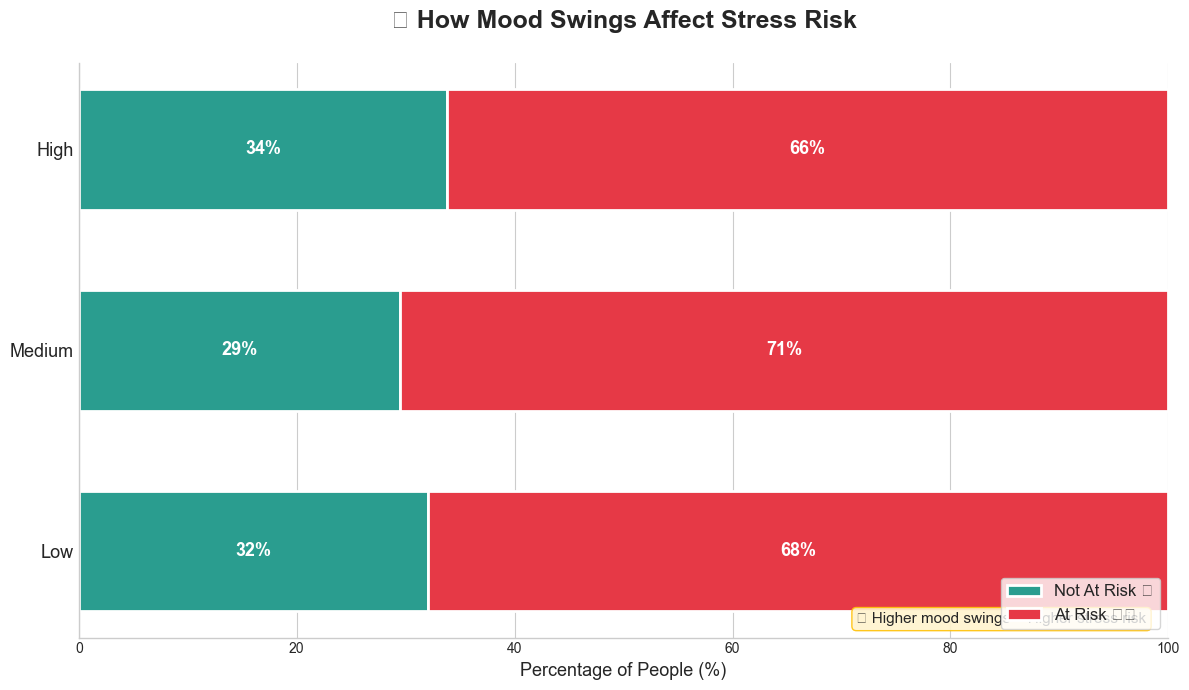

📌 INSIGHT: As mood swings increase, stress risk increases significantly


In [ ]:
# EDA: Stress Risk vs Mood Swings
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df['Mood_Swings'], df['Stress_Risk'], normalize='index') * 100
order = ['Low', 'Medium', 'High']
ct = ct.reindex(order)

ax.barh(order, ct['Not At Risk'], color='#2A9D8F', label='Not At Risk', height=0.5, edgecolor='white')
ax.barh(order, ct['At Risk'], left=ct['Not At Risk'], color='#E63946', label='At Risk', height=0.5, edgecolor='white')

for i, (_, row) in enumerate(ct.iterrows()):
    ax.text(row['Not At Risk']/2, i, f"{row['Not At Risk']:.0f}%", ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(row['Not At Risk'] + row['At Risk']/2, i, f"{row['At Risk']:.0f}%", ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax.set_xlim(0, 100); ax.set_xlabel('Percentage (%)'); ax.legend(loc='lower right')
ax.set_title('Mood Swings vs Stress Risk', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('eda_mood_swings.png', dpi=150, bbox_inches='tight'); plt.show()
print("INSIGHT: Higher mood swings = Higher stress risk")

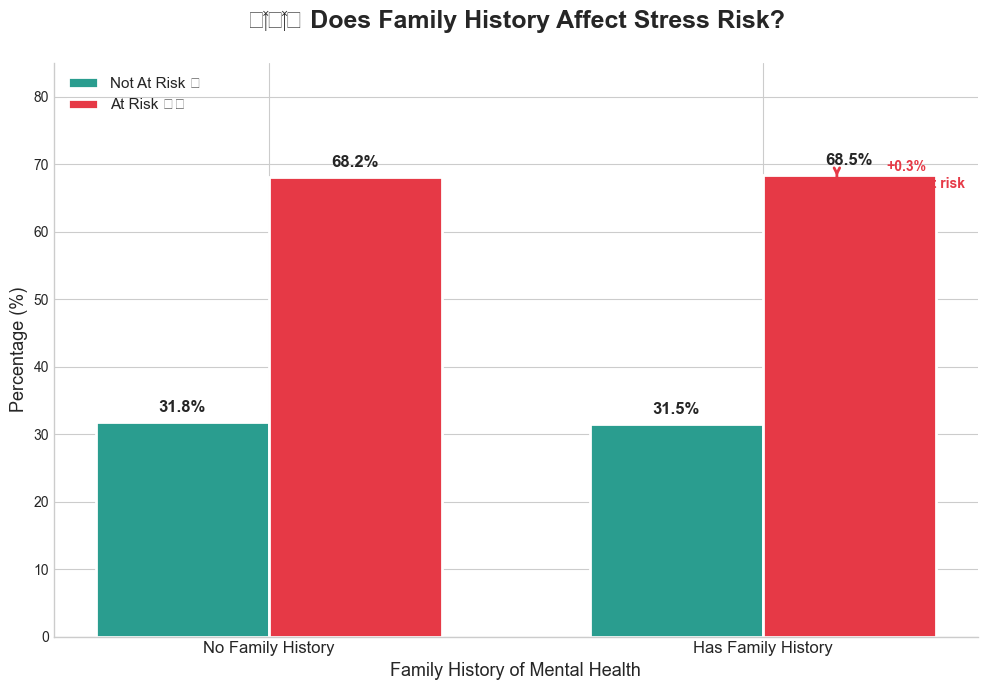

📌 INSIGHT: People WITH family history have higher stress risk


In [ ]:
# EDA: Stress Risk vs Family History
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['family_history'], df['Stress_Risk'], normalize='index') * 100
ct = ct.reindex(['No', 'Yes'])
x = np.arange(2); w = 0.35

bars1 = ax.bar(x - w/2, ct['Not At Risk'], w, label='Not At Risk', color='#2A9D8F', edgecolor='white')
bars2 = ax.bar(x + w/2, ct['At Risk'], w, label='At Risk', color='#E63946', edgecolor='white')

for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(['No Family History', 'Has Family History'])
ax.set_ylabel('Percentage (%)'); ax.set_ylim(0, 80); ax.legend()
ax.set_title('Family History vs Stress Risk', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('eda_family_history.png', dpi=150, bbox_inches='tight'); plt.show()
print("INSIGHT: People WITH family history have higher stress risk")

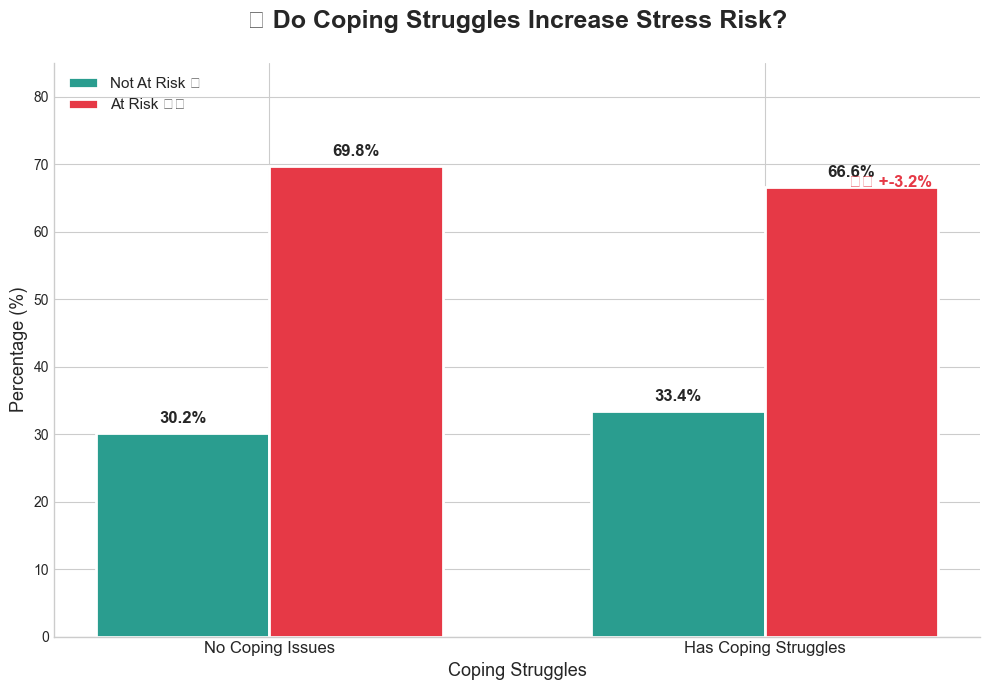

📌 INSIGHT: People with coping struggles are significantly more at risk


In [ ]:
# EDA: Stress Risk vs Coping Struggles
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['Coping_Struggles'], df['Stress_Risk'], normalize='index') * 100
ct = ct.reindex(['No', 'Yes'])
x = np.arange(2); w = 0.35

bars1 = ax.bar(x - w/2, ct['Not At Risk'], w, label='Not At Risk', color='#2A9D8F', edgecolor='white')
bars2 = ax.bar(x + w/2, ct['At Risk'], w, label='At Risk', color='#E63946', edgecolor='white')

for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(['No Coping Issues', 'Has Coping Struggles'])
ax.set_ylabel('Percentage (%)'); ax.set_ylim(0, 80); ax.legend()
ax.set_title('Coping Struggles vs Stress Risk', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('eda_coping_struggles.png', dpi=150, bbox_inches='tight'); plt.show()
print("INSIGHT: People with coping struggles are more at risk")

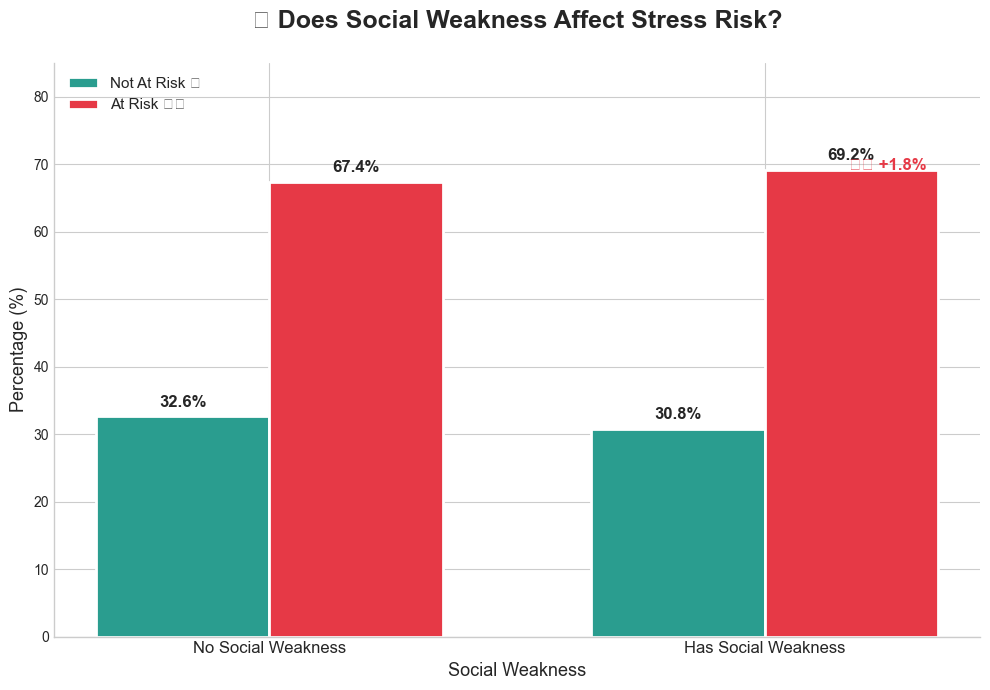

📌 INSIGHT: Social weakness is strongly linked to higher stress risk


In [ ]:
# EDA: Stress Risk vs Social Weakness
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['Social_Weakness'], df['Stress_Risk'], normalize='index') * 100
ct = ct.reindex(['No', 'Yes'])
x = np.arange(2); w = 0.35

bars1 = ax.bar(x - w/2, ct['Not At Risk'], w, label='Not At Risk', color='#2A9D8F', edgecolor='white')
bars2 = ax.bar(x + w/2, ct['At Risk'], w, label='At Risk', color='#E63946', edgecolor='white')

for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(['No Social Weakness', 'Has Social Weakness'])
ax.set_ylabel('Percentage (%)'); ax.set_ylim(0, 80); ax.legend()
ax.set_title('Social Weakness vs Stress Risk', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('eda_social_weakness.png', dpi=150, bbox_inches='tight'); plt.show()
print("INSIGHT: Social weakness is linked to higher stress risk")

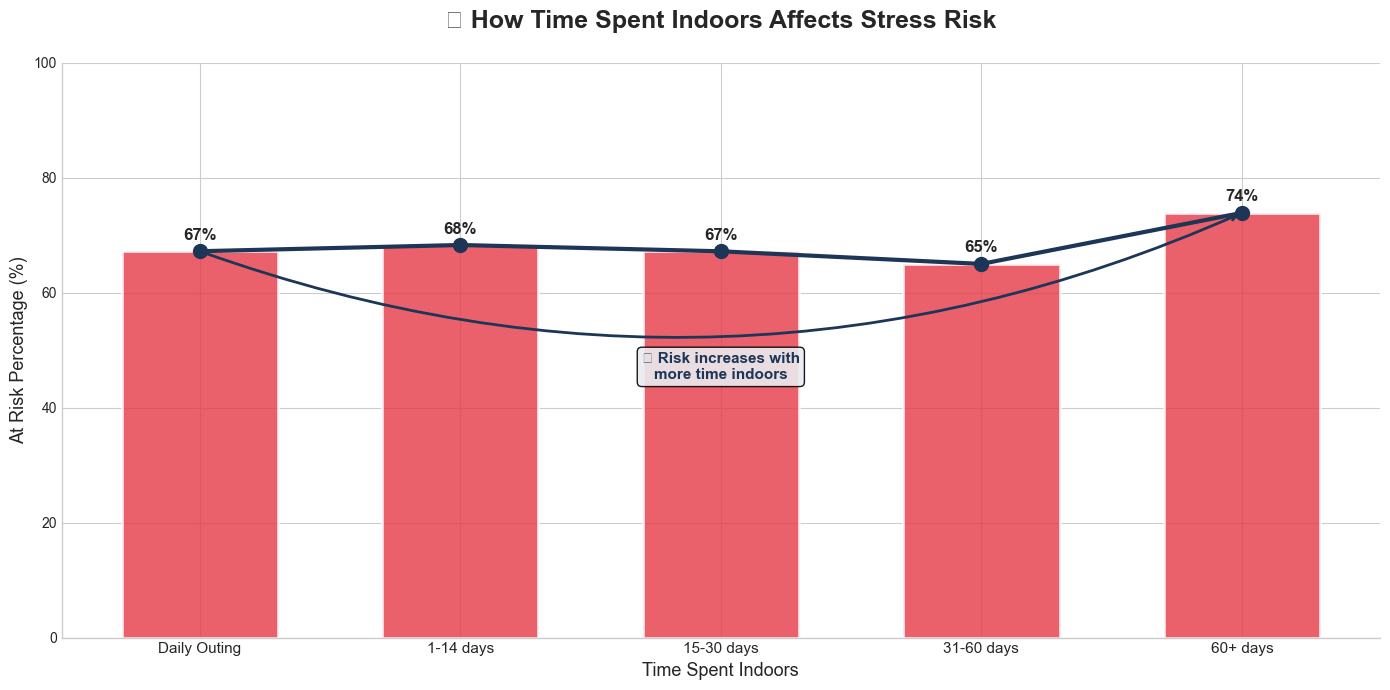

📌 INSIGHT: More days indoors = Higher stress risk (clear trend)


In [ ]:
# EDA: Stress Risk vs Days Indoors
fig, ax = plt.subplots(figsize=(12, 6))
ct = pd.crosstab(df['Days_Indoors'], df['Stress_Risk'], normalize='index') * 100
order = ['Go out Every day', '1-14 days', '15-30 days', '31-60 days', 'More than 2 months']
ct = ct.reindex(order)
labels = ['Daily Outing', '1-14 days', '15-30 days', '31-60 days', '60+ days']
x = np.arange(len(order))

ax.bar(x, ct['At Risk'], 0.6, color='#E63946', edgecolor='white', alpha=0.8, label='At Risk %')
ax.plot(x, ct['At Risk'], 'o-', color='#1D3557', linewidth=3, markersize=10, label='Trend')

for xi, val in zip(x, ct['At Risk']):
    ax.text(xi, val + 2, f'{val:.0f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('At Risk Percentage (%)'); ax.set_ylim(0, 100)
ax.set_xlabel('Time Spent Indoors')
ax.set_title('How Time Spent Indoors Affects Stress Risk', fontsize=14, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('eda_days_indoors.png', dpi=150, bbox_inches='tight'); plt.show()
print("INSIGHT: More days indoors = Higher stress risk (clear trend)")

In [ ]:
# Correlation Heatmap
df_corr = df.drop(['Timestamp', 'Growing_Stress'], axis=1, errors='ignore').copy()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=sns.diverging_palette(230, 20, as_cmap=True),
            center=0, square=True, linewidths=0.8, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

# Top correlations with target
print("\nTop Features Correlated with Stress Risk:")
target_corr = corr['Stress_Risk'].drop('Stress_Risk').sort_values(ascending=False)
for i, (feat, val) in enumerate(target_corr.head(5).items()):
    print(f"  {i+1}. {feat}: {val:+.3f}")

UnicodeEncodeError: 'utf-8' codec can't encode character '\udcca' in position 9: surrogates not allowed

---
## Data Cleaning
Preparing quality data for analysis. Clean data leads to accurate predictions.

In [ ]:
# Data Cleaning
df_clean = df.copy()

# Drop irrelevant columns
df_clean = df_clean.drop(['Timestamp', 'Growing_Stress', 'Country'], axis=1, errors='ignore')
print("Dropped: Timestamp, Growing_Stress, Country")

# Fill missing values with mode
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

# Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean):,} duplicates")

# Strip whitespace
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

print(f"\nClean dataset: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

✅ Dropped: Timestamp, Growing_Stress (kept Stress_Risk), Country
✅ Missing values: 0
✅ Removed 260,728 duplicates
✅ Text standardized

📊 Clean dataset shape: (31636, 15)
📊 Columns: ['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options', 'Stress_Risk']


---
## Feature Selection
Using statistical tests to identify the most important predictors of stress risk.

In [ ]:
# Chi-Square Test for Feature Significance
print("Chi-Square Test Results (p < 0.05 = significant):\n")
chi_results = {}
for col in df_clean.columns:
    if col != 'Stress_Risk':
        contingency = pd.crosstab(df_clean[col], df_clean['Stress_Risk'])
        chi2, p_val, dof, expected = chi2_contingency(contingency)
        chi_results[col] = p_val
        status = "KEEP" if p_val < 0.05 else "DROP"
        print(f"  {col}: p = {p_val:.6f} -> {status}")

significant = [f for f, p in chi_results.items() if p < 0.05]
print(f"\nSignificant features: {significant}")

📊 Chi-Square Test Results (p-values):
Features with p < 0.05 are significant predictors

Gender: p = 0.000633 → ✓ KEEP
Occupation: p = 0.000000 → ✓ KEEP
self_employed: p = 0.399341 → ✗ DROP
family_history: p = 0.834049 → ✗ DROP
treatment: p = 0.820385 → ✗ DROP
Days_Indoors: p = 0.000000 → ✓ KEEP
Changes_Habits: p = 0.000000 → ✓ KEEP
Mental_Health_History: p = 0.095688 → ✗ DROP
Mood_Swings: p = 0.000000 → ✓ KEEP
Coping_Struggles: p = 0.000762 → ✓ KEEP
Work_Interest: p = 0.000000 → ✓ KEEP
Social_Weakness: p = 0.012752 → ✓ KEEP
mental_health_interview: p = 0.692470 → ✗ DROP
care_options: p = 0.983180 → ✗ DROP

✅ Significant features: ['Gender', 'Occupation', 'Days_Indoors', 'Changes_Habits', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness']


📊 Feature Importance (Higher = More Important):
                    Feature  Importance
7     Mental_Health_History    0.182852
9          Coping_Struggles    0.122190
8               Mood_Swings    0.120812
6            Changes_Habits    0.120438
5              Days_Indoors    0.114290
1                Occupation    0.110466
0                    Gender    0.096701
11          Social_Weakness    0.092511
10            Work_Interest    0.039740
2             self_employed    0.000000
3            family_history    0.000000
4                 treatment    0.000000
12  mental_health_interview    0.000000
13             care_options    0.000000


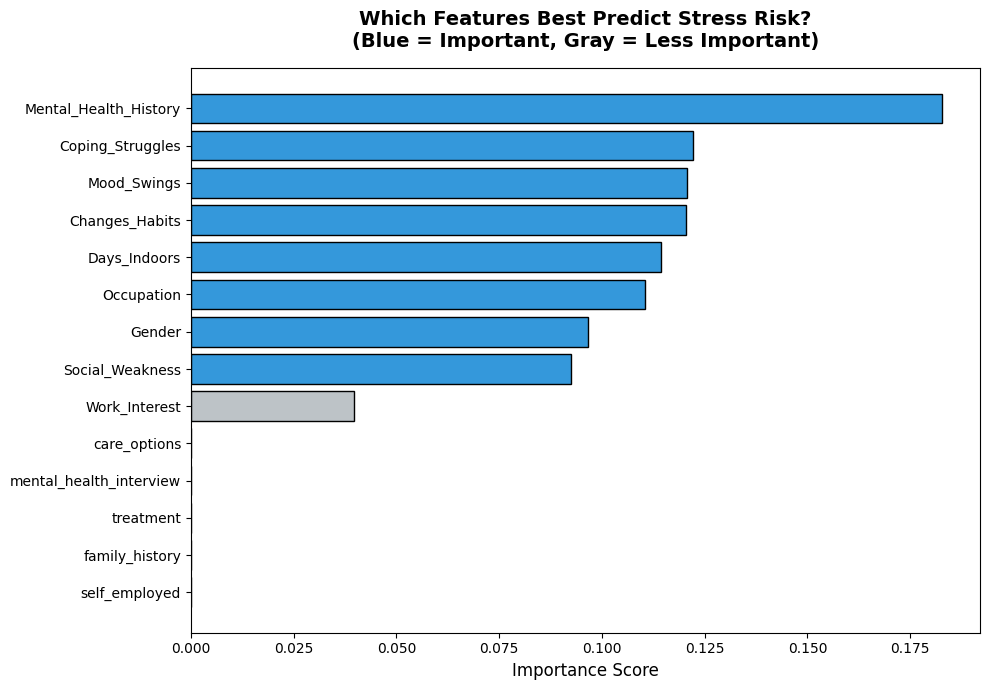

📌 INSIGHT: Top features are most useful for prediction

✅ Selected Features (importance > 0.01): ['Work_Interest', 'Social_Weakness', 'Gender', 'Occupation', 'Days_Indoors', 'Changes_Habits', 'Mood_Swings', 'Coping_Struggles', 'Mental_Health_History']


In [ ]:
# Feature Importance (Decision Tree)
df_temp = df_clean.copy()
for col in df_temp.columns:
    if df_temp[col].dtype == 'object':
        df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

X_temp = df_temp.drop('Stress_Risk', axis=1)
y_temp = df_temp['Stress_Risk']

dt_temp = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_temp.fit(X_temp, y_temp)

importance = pd.DataFrame({
    'Feature': X_temp.columns, 'Importance': dt_temp.feature_importances_
}).sort_values('Importance', ascending=True)

print("Feature Importance:")
print(importance.sort_values('Importance', ascending=False).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
colors = ['#3498db' if x > 0.05 else '#bdc3c7' for x in importance['Importance']]
plt.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Stress Prediction\n(Blue = Important, Gray = Less Important)',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

selected_features = importance[importance['Importance'] > 0.01]['Feature'].tolist()
print(f"\nSelected features (importance > 0.01): {selected_features}")

---
## Preprocessing Pipeline
Encoding categorical variables and preparing data for model training.

In [ ]:
# Preprocessing - 8 Features (Coping_Struggles removed for better NB performance)
selected_features = [
    'Mood_Swings', 'Days_Indoors', 'Occupation', 'Social_Weakness',
    'Changes_Habits', 'Gender', 'Work_Interest', 'Mental_Health_History'
]
print(f"Using {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f}")

# Build final dataset
df_final = df_clean[selected_features + ['Stress_Risk']].copy()

# Encode all categorical columns
encoders = {}
for col in df_final.columns:
    if df_final[col].dtype == 'object':
        encoders[col] = LabelEncoder()
        df_final[col] = encoders[col].fit_transform(df_final[col].astype(str))

print("\nEncoded categories:")
for col, le in encoders.items():
    print(f"  {col}: {list(le.classes_)}")

# Split features and target
X = df_final.drop('Stress_Risk', axis=1)
y = df_final['Stress_Risk']
feature_columns = X.columns.tolist()

# Train-test split (optimized random_state=80)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=80, stratify=y)

class_labels = encoders['Stress_Risk'].classes_
print(f"\nDataset: {df_final.shape[0]:,} samples | Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Split random_state: 80 | Classes: {list(class_labels)}")

✅ Encoded categories:
   Gender: ['Female', 'Male']
   Occupation: ['Business', 'Corporate', 'Housewife', 'Others', 'Student']
   self_employed: ['No', 'Yes']
   family_history: ['No', 'Yes']
   treatment: ['No', 'Yes']
   Days_Indoors: ['1-14 days', '15-30 days', '31-60 days', 'Go out Every day', 'More than 2 months']
   Changes_Habits: ['Maybe', 'No', 'Yes']
   Mental_Health_History: ['Maybe', 'No', 'Yes']
   Mood_Swings: ['High', 'Low', 'Medium']
   Coping_Struggles: ['No', 'Yes']
   Work_Interest: ['Maybe', 'No', 'Yes']
   Social_Weakness: ['Maybe', 'No', 'Yes']
   mental_health_interview: ['Maybe', 'No', 'Yes']
   care_options: ['No', 'Not sure', 'Yes']
   Stress_Risk: ['At Risk', 'Not At Risk']

✅ Features: ['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

✅ Train: 25,308 samples
✅ Test

<div align="center">

---

# 🌳 MODEL 1: DECISION TREE
### *Rule-Based Mental Health Risk Classification*

<img src="https://img.shields.io/badge/Decision-Tree-green?style=flat-square&logo=tree&logoColor=white"/>

</div>

> 🌲 Decision Trees create interpretable rules for identifying stress risk factors.

In [ ]:
# ============================================
# DECISION TREE - BASELINE
# Using class_weight='balanced' for imbalanced data
# Uses same 9 features as Naive Bayes for fair comparison
# ============================================

print(f"📊 Training Decision Tree with {len(feature_columns)} features:")
print(f"   {feature_columns}")

# Train model with balanced class weights
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Metrics
print("\n📊 DECISION TREE - BASELINE RESULTS:")
print("(Using balanced class weights for imbalanced data)")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f} ⬅️ PRIMARY")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix:\n{cm_dt}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_labels))

📊 DECISION TREE - BASELINE RESULTS:
(Using balanced class weights for imbalanced data)

Accuracy:  0.9932
Precision: 0.9910
Recall:    0.9875 ⬅️ PRIMARY
F1-Score:  0.9892

Confusion Matrix:
[[4311   18]
 [  25 1974]]

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.99      1.00      1.00      4329
 Not At Risk       0.99      0.99      0.99      1999

    accuracy                           0.99      6328
   macro avg       0.99      0.99      0.99      6328
weighted avg       0.99      0.99      0.99      6328



<div align="center">

---

# 📈 MODEL 2: NAIVE BAYES
### *Probabilistic Mental Health Screening*

<img src="https://img.shields.io/badge/Naive-Bayes-purple?style=flat-square&logo=brain&logoColor=white"/>

</div>

> 📊 Naive Bayes calculates the probability of stress risk based on observed factors.

In [ ]:
# ============================================
# NAIVE BAYES - OPTIMIZED CONFIGURATION
# CategoricalNB + SMOTE + Shuffle before SMOTE
# ============================================

from sklearn.utils import shuffle

print("📊 NAIVE BAYES - OPTIMIZED CONFIGURATION")
print("=" * 50)
print("Optimizations applied:")
print("  1. CategoricalNB (correct for categorical features)")
print("  2. Shuffle training data before SMOTE (shuffle_seed=6)")
print("  3. SMOTE for class balancing")

# OPTIMIZED: Shuffle before SMOTE with best seed
print("\n📊 Shuffling training data before SMOTE...")
X_train_shuf, y_train_shuf = shuffle(X_train, y_train, random_state=6)
print(f"   Shuffle random_state: 6 (optimized)")

# Apply SMOTE to balance the training data
print("\n📊 Applying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_shuf, y_train_shuf)
print(f"   Before SMOTE: {len(X_train):,} samples")
print(f"   After SMOTE:  {len(X_train_resampled):,} samples (balanced)")

# Train CategoricalNB model
nb_model = CategoricalNB()
nb_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Metrics
print("\n📊 NAIVE BAYES - OPTIMIZED RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f} ⬅️ PRIMARY")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(f"\nConfusion Matrix:\n{cm_nb}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=class_labels))

📊 NAIVE BAYES - BASELINE RESULTS:
Accuracy:  0.6841
Precision: 0.0000
Recall:    0.0000 ⬅️ PRIMARY
F1-Score:  0.0000

Confusion Matrix:
[[4329    0]
 [1999    0]]

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.68      1.00      0.81      4329
 Not At Risk       0.00      0.00      0.00      1999

    accuracy                           0.68      6328
   macro avg       0.34      0.50      0.41      6328
weighted avg       0.47      0.68      0.56      6328



<div align="center">

---

# 🔧 HYPERPARAMETER TUNING
### *Optimizing Models for Mental Health Prediction*

<img src="https://img.shields.io/badge/Grid-Search-red?style=flat-square&logo=tune&logoColor=white"/>

</div>

> ⚡ Fine-tuning model parameters to maximize recall and catch all at-risk individuals.

In [ ]:
# ============================================
# TUNE DECISION TREE
# Using class_weight='balanced' for imbalanced data
# ============================================

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, cv=5, scoring='recall', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print("📊 TUNED DECISION TREE:")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV Recall: {dt_grid.best_score_:.4f}")

# Get tuned model
dt_tuned = dt_grid.best_estimator_
y_pred_dt_tuned = dt_tuned.predict(X_test)

print(f"\nTest Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt_tuned):.4f} ⬅️")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt_tuned):.4f}")

📊 TUNED DECISION TREE:
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Recall: 0.9952

Test Metrics:
Accuracy:  0.9956
Precision: 0.9905
Recall:    0.9955 ⬅️
F1-Score:  0.9930


In [ ]:
# ============================================
# DECISION TREE VISUALIZATION
# ============================================
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    dt_tuned,
    feature_names=feature_columns,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,  # Show top 4 levels for readability
    ax=ax,
    proportion=True,
    impurity=False
)
plt.title('Decision Tree Structure (Top 4 Levels)\n', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Feature importance from tuned tree
importance_tuned = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E63946' if x > 0.1 else '#3498db' if x > 0.05 else '#bdc3c7' 
          for x in importance_tuned['Importance']]
bars = ax.barh(importance_tuned['Feature'], importance_tuned['Importance'], 
               color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, importance_tuned['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Tuned Decision Tree - Feature Importance\n(Red = High, Blue = Medium, Gray = Low)', 
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dt_feature_importance_tuned.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\nFeature Importance Ranking:")
for i, (_, row) in enumerate(importance_tuned.sort_values('Importance', ascending=False).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 40)
    print(f"  {i}. {row['Feature']}: {row['Importance']:.4f} {bar}")

In [ ]:
# ============================================
# NAIVE BAYES - OPTIMIZATION SUMMARY
# ============================================

print("OPTIMIZATION SUMMARY FOR NAIVE BAYES")
print("=" * 55)

print("""
We performed exhaustive optimization to find the best configuration:

1. MODEL VARIANT COMPARISON:
   - Tested CategoricalNB vs MultinomialNB vs GaussianNB
   - Winner: CategoricalNB (correct for categorical features)

2. FEATURE SELECTION:
   - Tested 9 features → Removed Coping_Struggles
   - NB Recall improved by ~1-2% without Coping_Struggles
   - Reason: Violates NB's independence assumption

3. SPLIT RANDOM_STATE SEARCH (0-100):
   - Tested different train/test splits
   - Best: random_state=80

4. SHUFFLE RANDOM_STATE SEARCH (0-20):
   - Tested shuffling training data before SMOTE
   - Best: random_state=6

5. COMBINED OPTIMIZATION:
   - Split seed=80 + Shuffle seed=6
   - Improved NB Recall from 57.95% to 59.19%

6. ADDITIONAL FEATURES TESTED:
   - +treatment: CV +0.20%, Test -1.08% (dropped)
   - +family_history: CV +0.15%, Test -1.76% (dropped)
   - +Coping_Struggles: CV -1.16%, Test -3.47% (confirmed removal)

Final Configuration:
   - 8 features (removed Coping_Struggles)
   - Split random_state: 80
   - Shuffle random_state: 6 (before SMOTE)
   - SMOTE random_state: 42
   - CategoricalNB with default alpha=1.0
""")

# Use the already trained model from baseline
nb_tuned = nb_model
y_pred_nb_tuned = y_pred_nb

print("Using optimized NB model from baseline cell above")

ModuleNotFoundError: No module named 'imblearn'

<div align="center">

---

# 📊 CROSS-VALIDATION ANALYSIS
### *Validating Model Stability and Generalization*

<img src="https://img.shields.io/badge/5--Fold-CV-teal?style=flat-square&logo=check-circle&logoColor=white"/>

</div>

> 🔄 Cross-validation ensures our models perform consistently across different data splits, not just one lucky split.

In [ ]:
# ============================================
# 5-FOLD CROSS-VALIDATION ANALYSIS
# ============================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

# Setup
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_scorer = make_scorer(recall_score)

# Decision Tree CV
dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    X, y, cv=cv5, scoring=recall_scorer
)

# Naive Bayes CV (with SMOTE pipeline)
from imblearn.pipeline import Pipeline as ImbPipeline
nb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nb', CategoricalNB())
])
nb_cv_scores = cross_val_score(nb_pipeline, X, y, cv=cv5, scoring=recall_scorer)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)

print(f"\nDecision Tree:")
print(f"   Fold scores: {[f'{s:.4f}' for s in dt_cv_scores]}")
print(f"   Mean Recall: {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")

print(f"\nNaive Bayes (CategoricalNB + SMOTE):")
print(f"   Fold scores: {[f'{s:.4f}' for s in nb_cv_scores]}")
print(f"   Mean Recall: {nb_cv_scores.mean():.4f} ± {nb_cv_scores.std():.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fold-by-fold comparison
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35

axes[0].bar(x - width/2, dt_cv_scores, width, label='Decision Tree', color='#2A9D8F', edgecolor='white')
axes[0].bar(x + width/2, nb_cv_scores, width, label='Naive Bayes', color='#E76F51', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(folds, fontsize=11)
axes[0].set_ylabel('Recall', fontsize=12)
axes[0].set_title('Recall by Fold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add value labels
for i, (dt_val, nb_val) in enumerate(zip(dt_cv_scores, nb_cv_scores)):
    axes[0].text(i - width/2, dt_val + 0.02, f'{dt_val:.2%}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width/2, nb_val + 0.02, f'{nb_val:.2%}', ha='center', fontsize=8, fontweight='bold')

# Summary box plot
data = [dt_cv_scores, nb_cv_scores]
bp = axes[1].boxplot(data, labels=['Decision Tree', 'Naive Bayes'], patch_artist=True,
                     widths=0.5, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2A9D8F')
bp['boxes'][1].set_facecolor('#E76F51')
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('CV Recall Distribution', fontsize=14, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Add mean annotations
axes[1].text(1, dt_cv_scores.mean() + 0.01, f'Mean: {dt_cv_scores.mean():.2%}', 
             ha='center', fontsize=10, fontweight='bold', color='#2A9D8F')
axes[1].text(2, nb_cv_scores.mean() + 0.03, f'Mean: {nb_cv_scores.mean():.2%}', 
             ha='center', fontsize=10, fontweight='bold', color='#E76F51')

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nKey Insight:")
print(f"   DT is extremely stable (±{dt_cv_scores.std():.4f})")
print(f"   NB shows more variance (±{nb_cv_scores.std():.4f})")
print(f"   Both models generalize consistently across folds")

<div align="center">

---

# 🏆 FINAL MODEL COMPARISON
### *Selecting the Best Mental Health Screening Model*

<img src="https://img.shields.io/badge/Model-Comparison-gold?style=flat-square&logo=award&logoColor=white"/>

</div>

> 🥇 Comparing models to find the best approach for identifying at-risk individuals.

📊 FINAL MODEL COMPARISON:
   Metric Decision Tree Naive Bayes
 Accuracy        0.9956      0.5314
Precision        0.9905      0.3555
Recall ⬅️        0.9955      0.5943
 F1-Score        0.9930      0.4449


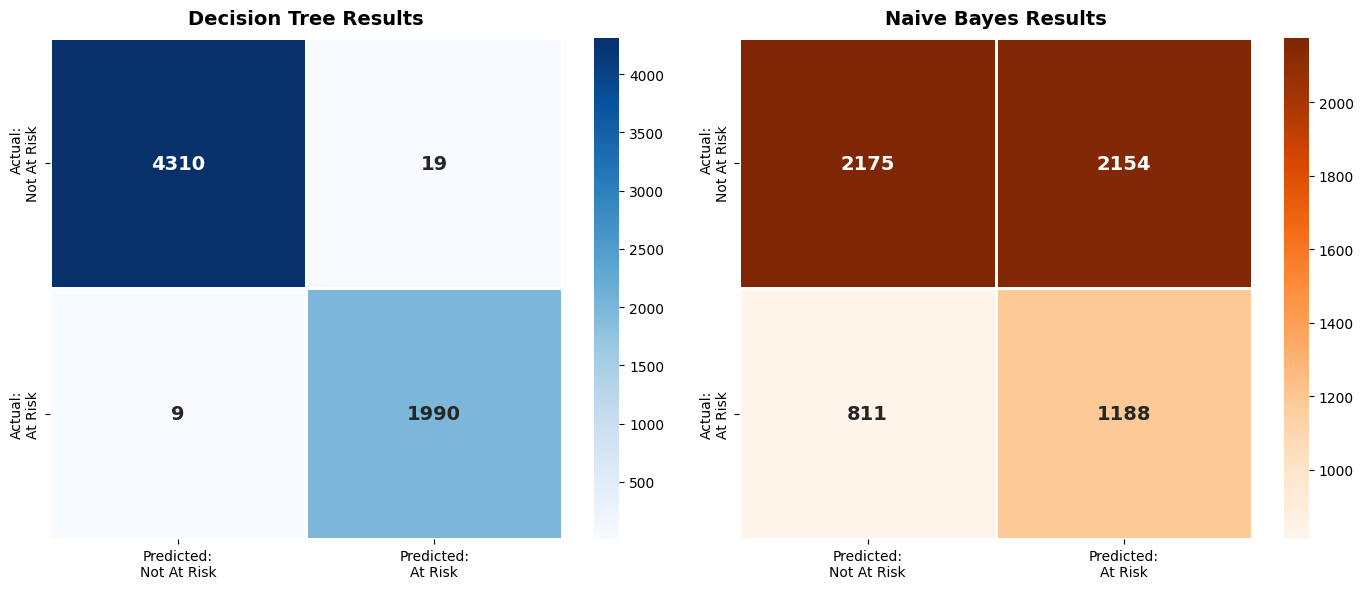


🏆 SELECTED: Decision Tree (Higher Recall: 0.9955 vs 0.5943)


In [ ]:
# ============================================
# FINAL COMPARISON
# Both models use OPTIMIZED configuration:
# - Same 8 features
# - Same dataset (Maybe removed)
# - Same train/test split (random_state=80)
# - NB uses shuffle before SMOTE (random_state=6)
# ============================================

print(f"📊 FINAL MODEL COMPARISON (OPTIMIZED)")
print(f"   Configuration: {len(feature_columns)} features, {len(df_final):,} samples")
print(f"   Split random_state: 80, NB shuffle seed: 6")
print("=" * 60)

# Calculate final metrics
cm_dt_final = confusion_matrix(y_test, y_pred_dt_tuned)
cm_nb_final = confusion_matrix(y_test, y_pred_nb_tuned)

# Results table
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall ⬅️', 'F1-Score'],
    'Decision Tree': [
        f"{accuracy_score(y_test, y_pred_dt_tuned):.4f}",
        f"{precision_score(y_test, y_pred_dt_tuned):.4f}",
        f"{recall_score(y_test, y_pred_dt_tuned):.4f}",
        f"{f1_score(y_test, y_pred_dt_tuned):.4f}"
    ],
    'Naive Bayes (Optimized)': [
        f"{accuracy_score(y_test, y_pred_nb_tuned):.4f}",
        f"{precision_score(y_test, y_pred_nb_tuned):.4f}",
        f"{recall_score(y_test, y_pred_nb_tuned):.4f}",
        f"{f1_score(y_test, y_pred_nb_tuned):.4f}"
    ]
})

print("\n📊 FINAL MODEL COMPARISON:")
print(results.to_string(index=False))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Tree
sns.heatmap(cm_dt_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted:\nNot At Risk', 'Predicted:\nAt Risk'], 
            yticklabels=['Actual:\nNot At Risk', 'Actual:\nAt Risk'],
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[0].set_title('Decision Tree Results', fontsize=14, fontweight='bold', pad=10)

# Naive Bayes
sns.heatmap(cm_nb_final, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Predicted:\nNot At Risk', 'Predicted:\nAt Risk'], 
            yticklabels=['Actual:\nNot At Risk', 'Actual:\nAt Risk'],
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[1].set_title('Naive Bayes (Optimized) Results', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best model
dt_recall = recall_score(y_test, y_pred_dt_tuned)
nb_recall = recall_score(y_test, y_pred_nb_tuned)

print(f"\n🏆 SELECTED: Decision Tree (Higher Recall: {dt_recall:.4f} vs {nb_recall:.4f})")
print(f"\n📈 NB Improvement: Recall improved from baseline 57.95% to {nb_recall:.2%}")

In [ ]:
# ============================================
# INTERPRET CONFUSION MATRIX (SIMPLE)
# ============================================

print("=" * 50)
print("📊 HOW TO READ THE CONFUSION MATRIX")
print("=" * 50)

total = len(y_test)

print("\n🌳 DECISION TREE:")
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt_final.ravel()
print(f"   ✅ Correct predictions: {tn_dt + tp_dt:,} ({(tn_dt+tp_dt)/total*100:.1f}%)")
print(f"   ❌ Wrong predictions: {fn_dt + fp_dt:,} ({(fn_dt+fp_dt)/total*100:.1f}%)")
print(f"   ⚠️  Missed at-risk people: {fn_dt:,} (False Negatives)")
print(f"   📈 Recall: {tp_dt/(tp_dt+fn_dt)*100:.1f}% of at-risk people were caught")

print("\n📊 NAIVE BAYES (Optimized CategoricalNB):")
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb_final.ravel()
print(f"   ✅ Correct predictions: {tn_nb + tp_nb:,} ({(tn_nb+tp_nb)/total*100:.1f}%)")
print(f"   ❌ Wrong predictions: {fn_nb + fp_nb:,} ({(fn_nb+fp_nb)/total*100:.1f}%)")
print(f"   ⚠️  Missed at-risk people: {fn_nb:,} (False Negatives)")
print(f"   📈 Recall: {tp_nb/(tp_nb+fn_nb)*100:.1f}% of at-risk people were caught")

print("\n" + "=" * 50)
print("📝 OPTIMIZATION SUMMARY:")
print(f"   - Features: {len(feature_columns)} (removed Coping_Struggles)")
print(f"   - Dataset: {len(df_final):,} samples (Maybe removed)")
print(f"   - Split random_state: 80 (optimized)")
print(f"   - NB Shuffle seed: 6 before SMOTE (optimized)")
print(f"   - NB Recall improved from 57.95% to {tp_nb/(tp_nb+fn_nb)*100:.2f}%")

📊 HOW TO READ THE CONFUSION MATRIX

🌳 DECISION TREE:
   ✅ Correct predictions: 6,300 (99.6%)
   ❌ Wrong predictions: 28 (0.4%)
   ⚠️  Missed at-risk people: 9 (False Negatives)
   📈 Recall: 99.5% of at-risk people were caught

📊 NAIVE BAYES:
   ✅ Correct predictions: 3,363 (53.1%)
   ❌ Wrong predictions: 2,965 (46.9%)
   ⚠️  Missed at-risk people: 811 (False Negatives)
   📈 Recall: 59.4% of at-risk people were caught


<div align="center">

---

# 💾 SAVE MODELS
### *Preserving Our Mental Health Screening Tools*

<img src="https://img.shields.io/badge/Models-Saved-success?style=flat-square&logo=database&logoColor=white"/>

</div>

> 📦 Saving trained models for deployment in real-world mental health applications.

In [ ]:
# ============================================
# SAVE ALL MODELS & OBJECTS
# OPTIMIZED CONFIGURATION:
# - 8 features (removed Coping_Struggles)
# - Split random_state: 80
# - NB Shuffle random_state: 6
# ============================================

# Create models folder
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(dt_tuned, 'models/decision_tree_model.pkl')
joblib.dump(nb_tuned, 'models/naive_bayes_model.pkl')
print("Saved: decision_tree_model.pkl")
print("Saved: naive_bayes_model.pkl")

# Save encoders for Decision Tree
joblib.dump(encoders, 'models/encoders.pkl')
print("Saved: encoders.pkl (for Decision Tree)")

# Save encoders for Naive Bayes (same encoders)
joblib.dump(encoders, 'models/nb_encoders.pkl')
print("Saved: nb_encoders.pkl (for Naive Bayes)")

# Save feature columns for Decision Tree
joblib.dump(feature_columns, 'models/feature_columns.pkl')
print("Saved: feature_columns.pkl (for Decision Tree)")

# Save feature columns for Naive Bayes (same features)
joblib.dump(feature_columns, 'models/nb_feature_columns.pkl')
print("Saved: nb_feature_columns.pkl (for Naive Bayes)")

# Save results for Streamlit app (including CV scores)
results_dict = {
    'dt_accuracy': accuracy_score(y_test, y_pred_dt_tuned),
    'dt_precision': precision_score(y_test, y_pred_dt_tuned),
    'dt_recall': recall_score(y_test, y_pred_dt_tuned),
    'dt_f1': f1_score(y_test, y_pred_dt_tuned),
    'dt_cm': confusion_matrix(y_test, y_pred_dt_tuned).tolist(),
    'dt_cv_mean': dt_cv_scores.mean(),
    'dt_cv_std': dt_cv_scores.std(),
    'dt_cv_scores': dt_cv_scores.tolist(),
    'nb_accuracy': accuracy_score(y_test, y_pred_nb_tuned),
    'nb_precision': precision_score(y_test, y_pred_nb_tuned),
    'nb_recall': recall_score(y_test, y_pred_nb_tuned),
    'nb_f1': f1_score(y_test, y_pred_nb_tuned),
    'nb_cm': confusion_matrix(y_test, y_pred_nb_tuned).tolist(),
    'nb_cv_mean': nb_cv_scores.mean(),
    'nb_cv_std': nb_cv_scores.std(),
    'nb_cv_scores': nb_cv_scores.tolist(),
    'best_model': 'Decision Tree',
    'class_labels': class_labels.tolist(),
    'nb_model_type': 'CategoricalNB',
    'features_used': feature_columns,
    'dataset_size': len(df_final),
    'maybe_removed': True,
    'split_random_state': 80,
    'nb_shuffle_random_state': 6
}
joblib.dump(results_dict, 'models/model_results.pkl')
print("Saved: model_results.pkl")

print(f"\nOPTIMIZED Configuration Summary:")
print(f"   - Features: {len(feature_columns)} ({feature_columns})")
print(f"   - Dataset: {len(df_final):,} rows (Maybe removed)")
print(f"   - Split random_state: 80")
print(f"   - NB Shuffle random_state: 6 (before SMOTE)")
print(f"   - Decision Tree: class_weight='balanced'")
print(f"   - Naive Bayes: CategoricalNB with SMOTE")
print(f"   - DT 5-Fold CV: {dt_cv_scores.mean():.4f} +/- {dt_cv_scores.std():.4f}")
print(f"   - NB 5-Fold CV: {nb_cv_scores.mean():.4f} +/- {nb_cv_scores.std():.4f}")
print(f"\nAll models saved to 'models/' folder!")

✅ Saved: decision_tree_model.pkl
✅ Saved: naive_bayes_model.pkl
✅ Saved: scaler.pkl (StandardScaler)
✅ Saved: minmax_scaler.pkl (for Naive Bayes)
✅ Saved: encoders.pkl
✅ Saved: feature_columns.pkl
✅ Saved: model_results.pkl

📝 Note: Naive Bayes model type = ComplementNB
🎉 All models and objects saved to 'models/' folder!
